# Aufgabe 5 - Hough-Transformation

**Aufgabe 1:** Lesen Sie die Kapitel 7, 8 und 9 aus dem Buch "Digitale Bildverarbeitung".

## Aufgabe 2: Implementierung der linearen Hough-Transformation

Die Hough-Transformation nutzt die **Hesse'sche Normalform (HNF)**:

$$d = x \cdot \cos(\theta) + y \cdot \sin(\theta)$$

Dabei gilt:
- $(x, y)$: Bildkoordinaten relativ zum Bildmittelpunkt
- $\theta \in [0, \pi)$: Winkel der Geraden-Normalen
- $d \in [-d_{max}, +d_{max}]$: senkrechter Abstand der Geraden vom Ursprung

Jeder Kantenpunkt erzeugt eine Sinuskurve im $(\theta, d)$-Parameterraum. Schnittpunkte dieser Kurven entsprechen gemeinsamen Geraden.

In [2]:
from skimage import io, filters, feature
import matplotlib.pyplot as plt
import numpy as np

c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [3]:
def linearHT(im_edge, angle_steps, radius_steps):
    """
    Hough-Transformation fuer Geraden (HNF).

    Parameter:
        im_edge      -- Binaerbild (bool), Kantenbild
        angle_steps  -- Anzahl Winkelschritte im Akkumulator (int)
        radius_steps -- Anzahl Radiusschritte im Akkumulator (int)

    Rueckgabe:
        hough_array  -- Akkumulatorbild (int), Shape: (angle_steps, radius_steps)
    """
    height, width = im_edge.shape

    # Bildmittelpunkt als Ursprung (analog zur Java-Vorlage)
    x_ctr = width // 2
    y_ctr = height // 2

    n_ang = angle_steps
    n_rad = radius_steps

    d_ang = np.pi / n_ang                          # Winkelschrittweite
    r_max = np.sqrt(x_ctr**2 + y_ctr**2)           # max. moeglicher Radius
    d_rad = (2 * r_max) / n_rad                    # Radiusschrittweite

    hough_array = np.zeros((n_ang, n_rad), dtype=int)

    # Vorberechnung der cos/sin-Werte fuer alle Winkelschritte
    thetas = np.arange(n_ang) * d_ang
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    # Alle Kantenpixel ermitteln
    ys, xs = np.where(im_edge)

    # Koordinaten relativ zum Bildmittelpunkt
    x_rel = xs - x_ctr
    y_rel = ys - y_ctr

    # Fuer jeden Kantenpunkt alle Winkel durchlaufen (vektorisiert)
    for a in range(n_ang):
        # d = x*cos(theta) + y*sin(theta), diskretisiert
        r = np.round(
            (x_rel * cos_t[a] + y_rel * sin_t[a]) / d_rad
        ).astype(int) + n_rad // 2

        # Nur gueltige Indizes beruecksichtigen
        valid = (r >= 0) & (r < n_rad)
        np.add.at(hough_array[a], r[valid], 1)

    return hough_array

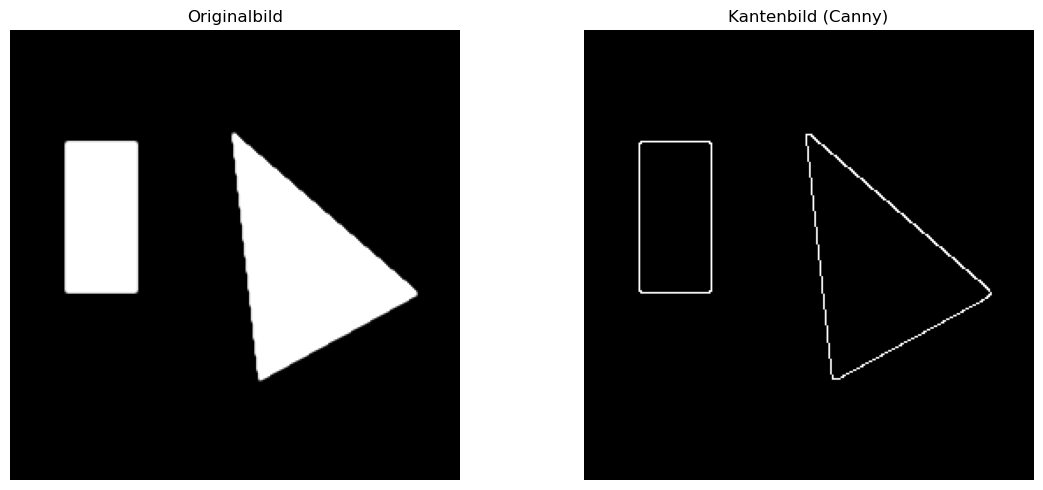

Kantenpixel: 675


In [4]:
# Testbild laden und Kantendetektion mit Canny
#img_raw = io.imread("noisy-lines.tif")
img_raw = io.imread("corner-test.tif", as_gray=True)

# Graustufen falls noetig
if img_raw.ndim == 3:
    gray = np.mean(img_raw[:, :, :3], axis=2)
else:
    gray = img_raw.astype(float)

# Canny-Kantendetektion liefert ein bool-Binaerbild
edges = feature.canny(gray / gray.max(), sigma=1.5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Originalbild")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Kantenbild (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
print(f"Kantenpixel: {edges.sum()}")

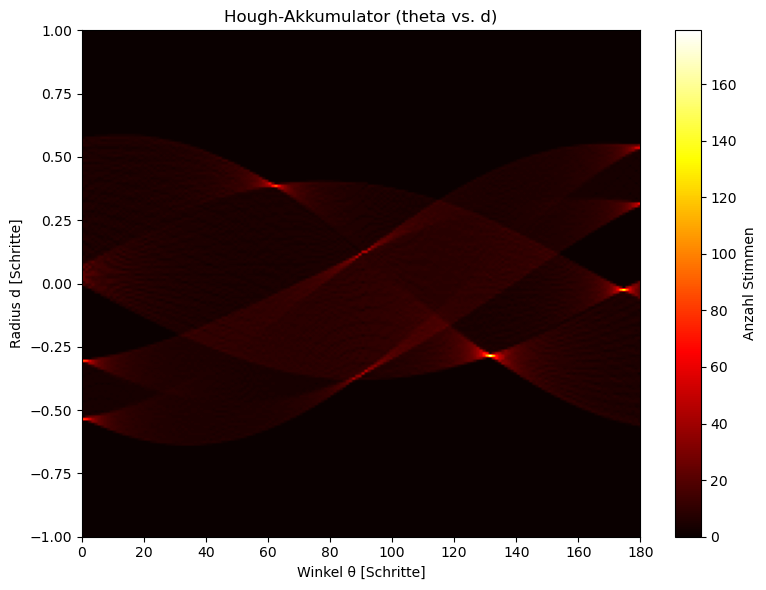

Maximaler Akkumulatorwert: 179


In [5]:
# Hough-Transformation berechnen
H = linearHT(edges, angle_steps=180, radius_steps=200)

plt.figure(figsize=(8, 6))
plt.title("Hough-Akkumulator (theta vs. d)")
plt.imshow(H.T, cmap='hot', aspect='auto',
           extent=[0, 180, -1, 1],   # nur zur visuellen Skalierung
           origin='lower')
plt.xlabel("Winkel θ [Schritte]")
plt.ylabel("Radius d [Schritte]")
plt.colorbar(label="Anzahl Stimmen")
plt.tight_layout()
plt.show()

print(f"Maximaler Akkumulatorwert: {H.max()}")

## Aufgabe 3: Schwellwertoperation

Um dominante Geraden zu extrahieren, wird ein Schwellwert auf den Hough-Akkumulator angewendet. Sinnvolle Schwellwerte liegen bei **50–80 % des Maximums**, da:
- Kurze oder schwach ausgeprägte Kanten wenige Stimmen erhalten
- Lange durchgängige Geraden viele Stimmen akkumulieren
- Ein zu niedriger Schwellwert führt zu vielen Falsch-Positiven

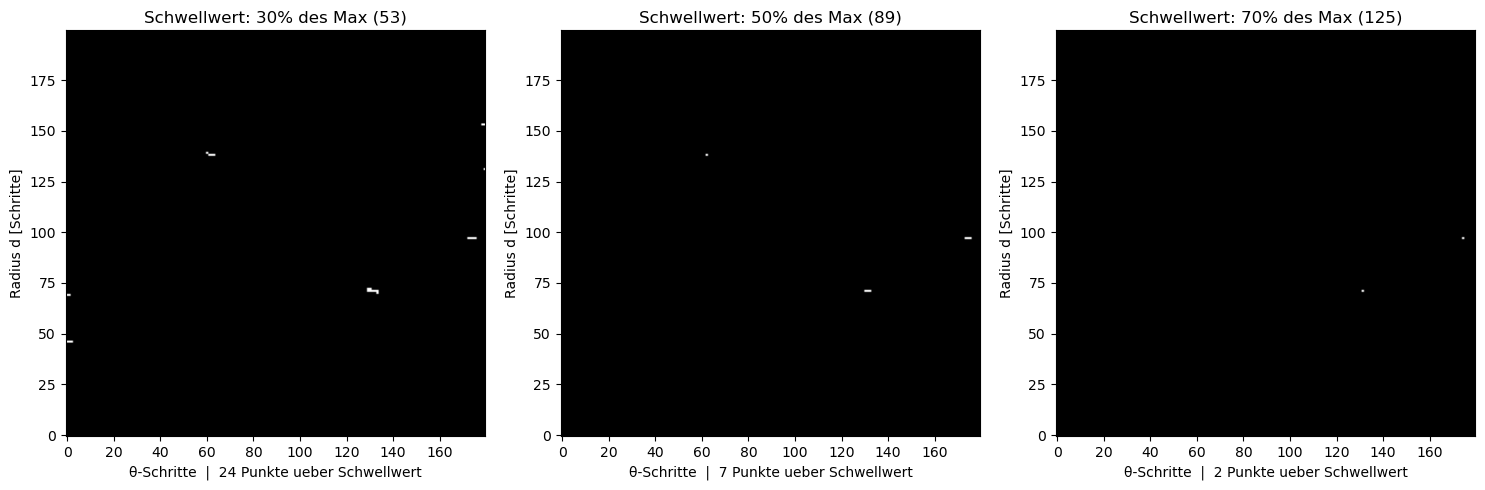

In [6]:
def threshold_hough(hough_array, threshold_ratio=0.5):
    """
    Schwellwertoperation auf dem Hough-Akkumulator.
    threshold_ratio: Anteil des Maximalwerts (z.B. 0.5 = 50%)
    Gibt ein bool-Array zurueck.
    """
    threshold = hough_array.max() * threshold_ratio
    return hough_array >= threshold


# Verschiedene Schwellwerte vergleichen
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ratio in zip(axes, [0.3, 0.5, 0.7]):
    mask = threshold_hough(H, ratio)
    ax.imshow(mask.T, cmap='gray', aspect='auto', origin='lower')
    ax.set_title(f"Schwellwert: {int(ratio*100)}% des Max ({int(H.max()*ratio)})")
    ax.set_xlabel("Winkel θ [Schritte]")
    ax.set_ylabel("Radius d [Schritte]")
    detected = mask.sum()
    ax.set_xlabel(f"θ-Schritte  |  {detected} Punkte ueber Schwellwert")

plt.tight_layout()
plt.show()

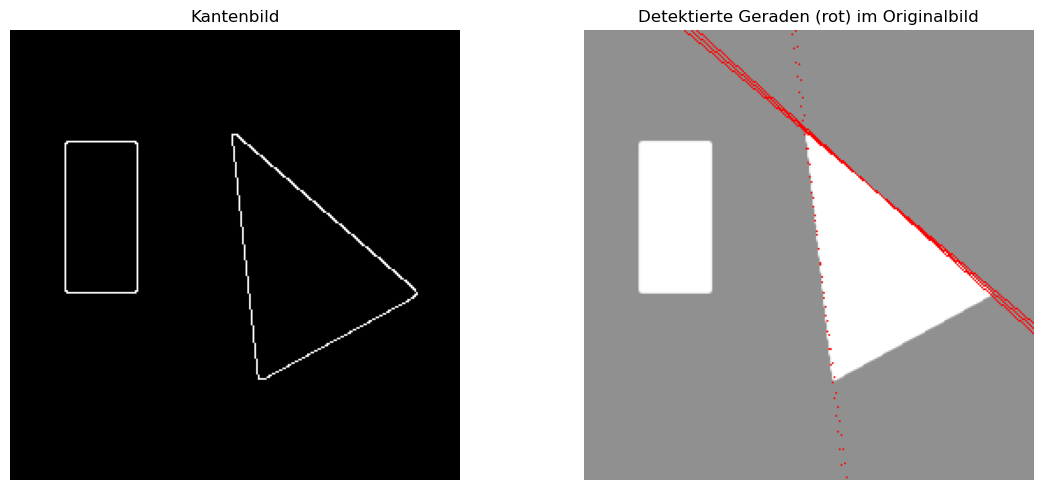

In [7]:
# Detektierte Geraden ins Originalbild einzeichnen
def draw_lines(image, hough_array, threshold_ratio, angle_steps, radius_steps):
    """
    Zeichnet detektierte Hough-Geraden in ein RGB-Bild ein.
    """
    height, width = image.shape
    x_ctr, y_ctr = width // 2, height // 2
    r_max = np.sqrt(x_ctr**2 + y_ctr**2)
    d_ang = np.pi / angle_steps
    d_rad = (2 * r_max) / radius_steps

    # RGB-Ausgabebild
    out = np.stack([image / image.max()] * 3, axis=-1)

    threshold = hough_array.max() * threshold_ratio
    peaks = np.argwhere(hough_array >= threshold)

    for (a_idx, r_idx) in peaks:
        theta = a_idx * d_ang
        d = (r_idx - radius_steps // 2) * d_rad
        cos_t, sin_t = np.cos(theta), np.sin(theta)

        # Gerade durch alle Spalten zeichnen (bei fast-senkrechten Geraden: durch Zeilen)
        if abs(sin_t) > 0.01:
            for u in range(width):
                x = u - x_ctr
                y_float = (d - x * cos_t) / sin_t
                v = int(round(y_float + y_ctr))
                if 0 <= v < height:
                    out[v, u] = [1.0, 0.0, 0.0]   # rot
        else:
            for v in range(height):
                y = v - y_ctr
                x_float = (d - y * sin_t) / cos_t
                u = int(round(x_float + x_ctr))
                if 0 <= u < width:
                    out[v, u] = [1.0, 0.0, 0.0]   # rot
    return out


result = draw_lines(gray, H, threshold_ratio=0.6, angle_steps=180, radius_steps=200)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Kantenbild")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Detektierte Geraden (rot) im Originalbild")
plt.imshow(result)
plt.axis('off')

plt.tight_layout()
plt.show()

## Aufgabe 4: Fragen zur Schwellwertoperation

### a) Wie können die Kanten im ursprünglichen Bild mit der Schwellwertoperation ermittelt werden?

Jede Zelle im Hough-Akkumulator, die den Schwellwert überschreitet, entspricht einem $(\theta, d)$-Parameterpaar – also einer konkreten Gerade in der HNF. Diese Gerade kann aus den Parametern zurückgerechnet und ins Originalbild eingezeichnet werden (siehe `draw_lines` oben). Damit lassen sich die dominierenden geradlinigen Kanten direkt im Bild lokalisieren.

Der Schwellwert kontrolliert die Selektivität: ein hoher Schwellwert liefert nur sehr lange, klar ausgeprägte Kanten (viele Kantenpixel auf einer Linie), ein niedriger Schwellwert auch kürzere oder verrauschte Linien.

---

### b) Welches sind die dominierendsten (längsten) Kanten?

Die Zellen mit den **höchsten Akkumulatorwerten** entsprechen den längsten Kanten, da mehr Kantenpixel auf dieselbe Gerade abstimmen. Die dominanten Kanten findet man als globale Maxima im Hough-Array:

In [8]:
# Top-5 dominierendste Geraden
n_ang, n_rad = H.shape
r_max = np.sqrt((gray.shape[1]//2)**2 + (gray.shape[0]//2)**2)
d_ang = np.pi / n_ang
d_rad = (2 * r_max) / n_rad

flat_idx = np.argsort(H.ravel())[::-1][:5]
a_idx, r_idx = np.unravel_index(flat_idx, H.shape)

print("Top-5 Geraden (Akkumulatorwert / theta / d):")
for rank, (a, r) in enumerate(zip(a_idx, r_idx), 1):
    theta_deg = np.degrees(a * d_ang)
    d_val = (r - n_rad // 2) * d_rad
    print(f"  #{rank}: Stimmen={H[a,r]:4d}, theta={theta_deg:.1f}°, d={d_val:.1f} px")

Top-5 Geraden (Akkumulatorwert / theta / d):
  #1: Stimmen= 179, theta=131.0°, d=-52.5 px
  #2: Stimmen= 141, theta=174.0°, d=-5.4 px
  #3: Stimmen= 120, theta=132.0°, d=-52.5 px
  #4: Stimmen= 117, theta=130.0°, d=-52.5 px
  #5: Stimmen= 108, theta=173.0°, d=-5.4 px


---

### c) Non-Maximum Suppression (NMS) als Alternative zur Schwellwertoperation

Bei der **Non-Maximum Suppression** wird jeder Akkumulatorwert nur dann beibehalten, wenn er das **lokale Maximum in einer definierten Nachbarschaft** (z. B. 3×3 oder 5×5 Fenster im $(\theta, d)$-Raum) ist. Ist ein Wert nicht das Maximum in seiner Umgebung, wird er auf 0 gesetzt.

**Vorgehen:**
1. Für jeden Punkt $(a, r)$ im Hough-Array: Bestimme das Maximum im umgebenden Fenster.
2. Behalte den Punkt nur, wenn er selbst das Maximum ist (= kein größerer Nachbar).
3. Optional: Kombiniere NMS mit einem minimalen Akkumulatorwert als untere Schranke.

**Vorteil gegenüber Schwellwert:** NMS liefert **genau einen** Punkt pro Geradenhäufung (den stärksten), während ein einfacher Schwellwert mehrere nahe beieinander liegende Punkte liefern kann, die dieselbe Gerade repräsentieren. Damit entfällt das Problem der doppelten Detektion ohne manuelles Tuning des Schwellwerts.